<a href="https://colab.research.google.com/github/PDM-15/AML-2026/blob/master/ML_Lab5_Sep1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simple Linear Regression

Intercept: 33.0
Slope: 7.0
Predicted Mark: 75.0


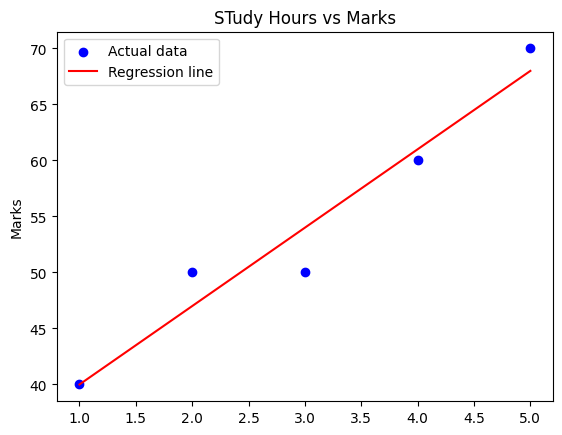

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

X = np.array([1,2,3,4,5]).reshape(-1,1)
y = np.array([40,50,50,60,70])

model = LinearRegression()
model.fit(X,y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

new_data = np.array([[6]])
predicted_mark = model.predict(new_data)
print("Predicted Mark:", predicted_mark[0])

y_pred = model.predict(X)

plt.scatter(X, y, color = "blue", label="Actual data")
plt.ylabel("Marks")
plt.title("STudy Hours vs Marks")
plt.plot(X, y_pred, color = "red", label="Regression line")
plt.legend()
plt.show()


Evaluating the python model

In [ ]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Absolute Error: 2.0
Mean Squared Error: 6.0
Root Mean Squared Error: 2.449489742783178
R-squared: 0.9423076923076923


Train - Test split

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = {"Study hours": [1,2,3,4,5,6,7,8,9,10],
        "Marks": [32,38,43,50,54,61,68,73,81,88]}

df = pd.DataFrame(data)

X = df[["Study hours"]]
y = df["Marks"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])
print("Actual values:", y_test.values)
print("Predicted values:", y_pred,"\n")

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared:", r2_score(y_test, y_pred))

Intercept: 24.724137931034484
Slope: 6.163793103448276
Actual values: [81 38]
Predicted values: [80.19827586 37.05172414] 

MAE: 0.875
MSE: 0.7709943519619504
RMSE: 0.8780628405541089
R-squared: 0.9983320836085193


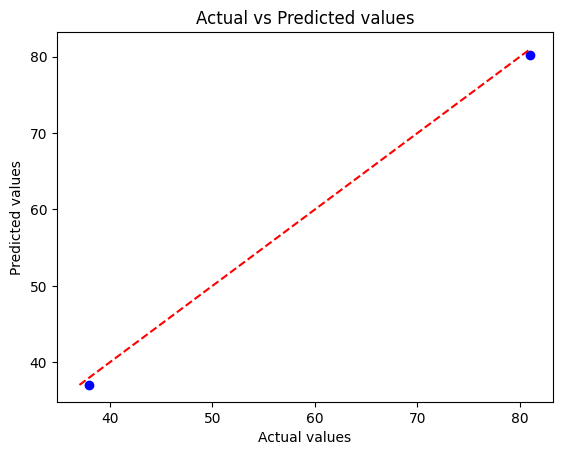

In [ ]:
plt.scatter(y_test, y_pred, color = "blue")

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot([minimum,maximum], [minimum,maximum], color = "red", linestyle = "--")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual vs Predicted values")
plt.show()


Residual plot

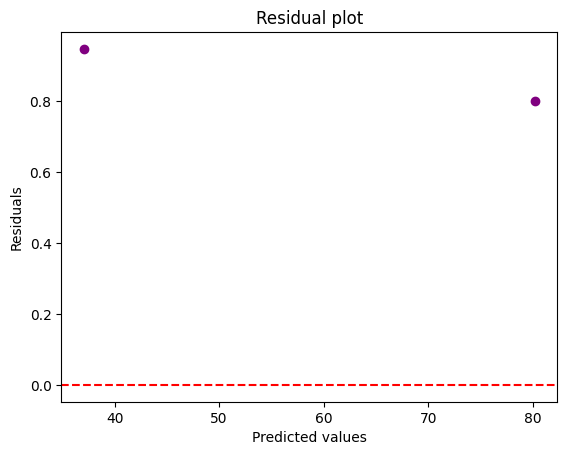

In [ ]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, color = "purple")
plt.axhline(y=0, color = "red", linestyle = "--")

plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residual plot")
plt.show()

Multiple Linear Regression

In [ ]:
data1 = {"Study Hours": [2,3,4,5,6,7,8,9],
        "Attendance": [60,65,70,75,80,85,90,95],
        "Assignment_score": [50,55,58,65,70,74,80,88],
        "Final_Marks": [42,48,54,61,67,73,81,89]}

df = pd.DataFrame(data1)

X = df[["Study Hours", "Attendance", "Assignment_score"]]
y = df["Final_Marks"]

model = LinearRegression()
model.fit(X,y)
print("Intercept:", model.intercept_)

coefficient_table = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
print(coefficient_table)

new_student = pd.DataFrame({"Study Hours":[6],
                            "Attendance":[82],
                            "Assignment_score":[72]})

prediction = model.predict(new_student)
print("Predicted final mark:", prediction[0])

Intercept: -28.31652806652808
            Feature  Coefficient
0       Study Hours     0.131410
1        Attendance     0.657051
2  Assignment_score     0.608108
Predicted final mark: 70.13392238392238


Study hours per week -> day * 7

In [ ]:
data1 = {"Study Hours_week": [14,21,28,35,42,49,56,63],
        "Attendance": [60,65,70,75,80,85,90,95],
        "Assignment_score": [50,55,58,65,70,74,80,88],
        "Final_Marks": [42,48,54,61,67,73,81,89]}

df = pd.DataFrame(data1)

X = df[["Study Hours_week", "Attendance", "Assignment_score"]]
y = df["Final_Marks"]

model = LinearRegression()
model.fit(X,y)
print("Intercept:", model.intercept_)

coefficient_table = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
print(coefficient_table)

new_student = pd.DataFrame({"Study Hours_week":[70],
                            "Attendance":[82],
                            "Assignment_score":[72]})

prediction = model.predict(new_student)
print("Predicted final mark:", prediction[0])

Intercept: -7.006756756756687
            Feature  Coefficient
0  Study Hours_week     0.323198
1        Attendance     0.230856
2  Assignment_score     0.608108
Predicted final mark: 78.33108108108108


Suppose house prediction data we have

In [ ]:
data = {"Size": [800, 1000, 1200, 1500, 1800],
        "Location": ["Rural", "Urban", "Rural", "Urban", "Urban"],
        "Price": [30, 50, 42, 72, 85]}
df = pd.DataFrame(data)

df_encoded = pd.get_dummies(df, columns=["Location"], drop_first=True, dtype=int)
print(df_encoded)

   Size  Price  Location_Urban
0   800     30               0
1  1000     50               1
2  1200     42               0
3  1500     72               1
4  1800     85               1


For CSV data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
'''import csv

headers = ["Study Hours_week", "Attendance", "Assignment_score", "Final_Marks"]
data = [[14,21,28,35,42,49,56,63],[60,65,70,75,80,85,90,95],[50,55,58,65,70,74,80,88],[42,48,54,61,67,73,81,89]]

with open('student_data.csv', 'w', newline='', encoding = 'utf-8') as file:
  writer = csv.writer(file)
  writer.writerow(headers)
  writer.writerows(data)

files.download('student_data.csv')'''

df.to_csv("drive/My Drive/Dataset/student_data.csv", index=False)

X = df[["Study Hours_week", "Attendance", "Assignment_score"]]
y = df["Final_Marks"]

model = LinearRegression()
model.fit(X,y)
print("Intercept:", model.intercept_)

coefficient_table = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
print(coefficient_table)

new_student = pd.DataFrame({"Study Hours_week":[70],
                            "Attendance":[82],
                            "Assignment_score":[72]})

prediction = model.predict(new_student)
print("Predicted final mark:", prediction[0])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Intercept: -7.006756756756687
            Feature  Coefficient
0  Study Hours_week     0.323198
1        Attendance     0.230856
2  Assignment_score     0.608108
Predicted final mark: 78.33108108108108
